In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [11]:
import os
os.listdir()

['all',
 'customer_data_analysis.csv',
 'customer_data_analysis.ipynb',
 'desktop.ini',
 'task2']

In [12]:
df = pd.read_csv('customer_data_analysis.csv')
df.head()
df.shape
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='str')

In [13]:
import pandas as pd
import os
print(os.listdir())

['all', 'customer_data_analysis.csv', 'customer_data_analysis.ipynb', 'desktop.ini', 'task2']


In [14]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.dtypes

Customer ID                int64
Purchase Date                str
Product Category             str
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method               str
Customer Age               int64
Returns                  float64
Customer Name                str
Age                        int64
Gender                       str
Churn                      int64
dtype: object

In [17]:
df['Purchase Date'] = pd.to_datetime(
    df['Purchase Date'],
    #dayfirst=True
)

In [18]:
df['Purchase Date'].head()

0   2023-05-03 21:30:02
1   2021-05-16 13:57:44
2   2020-07-13 06:16:57
3   2023-01-17 13:14:36
4   2021-05-01 11:29:27
Name: Purchase Date, dtype: datetime64[us]

In [19]:
df['Month'] = df['Purchase Date'].dt.month
df['Year'] = df['Purchase Date'].dt.year

In [20]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [21]:
df.describe()
df.median(numeric_only=True)
df.mode().head()
missing_values = df.isnull().sum()
print(missing_values)

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
Month                        0
Year                         0
dtype: int64


In [22]:
df['Revenue'] = df['Total Purchase Amount']
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df['Month'] = df['Purchase Date'].dt.month
df['Year'] = df['Purchase Date'].dt.year

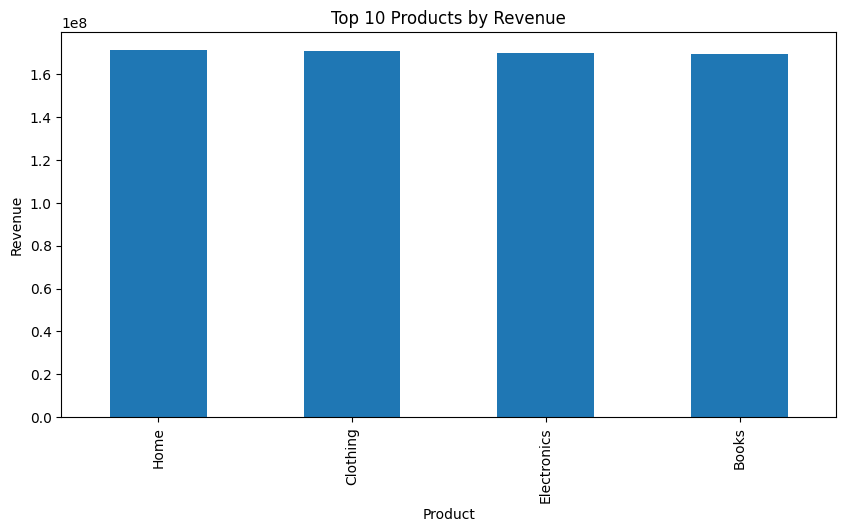

In [23]:
top_products = df.groupby('Product Category')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

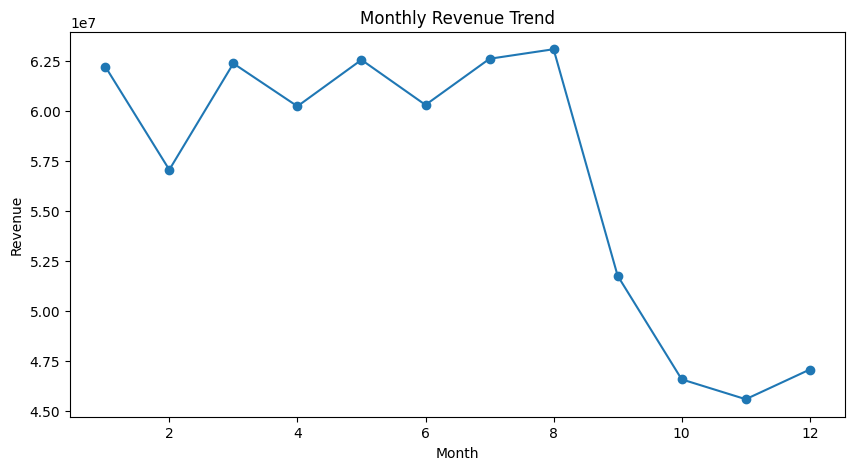

In [24]:
monthly_sales = df.groupby('Month')['Revenue'].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

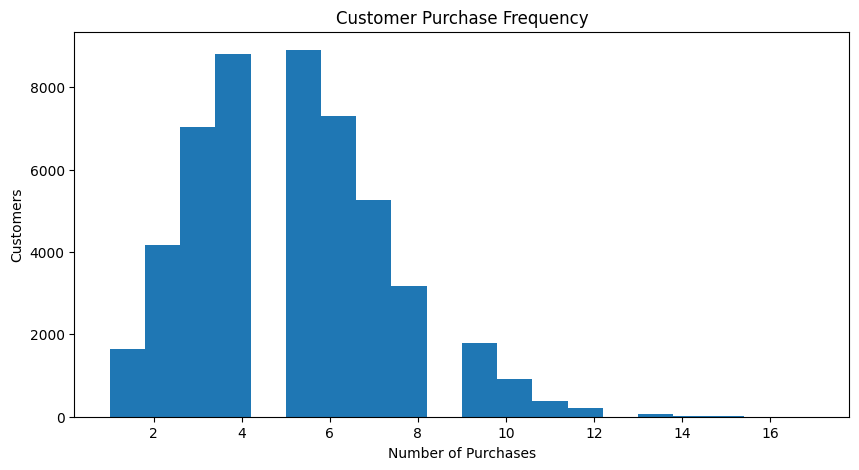

In [25]:
purchase_freq = df.groupby('Customer ID')['Purchase Date'].count()
plt.figure(figsize=(10,5))
plt.hist(purchase_freq, bins=20)
plt.title('Customer Purchase Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Customers')
plt.show()

In [26]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': [
        lambda x: (snapshot_date - x.max()).days,
        'count'
    ],
    'Total Purchase Amount': 'sum'
})

In [27]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,289,3,6290
2,73,6,16481
3,223,4,9423
4,442,5,7826
5,425,5,9769


In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

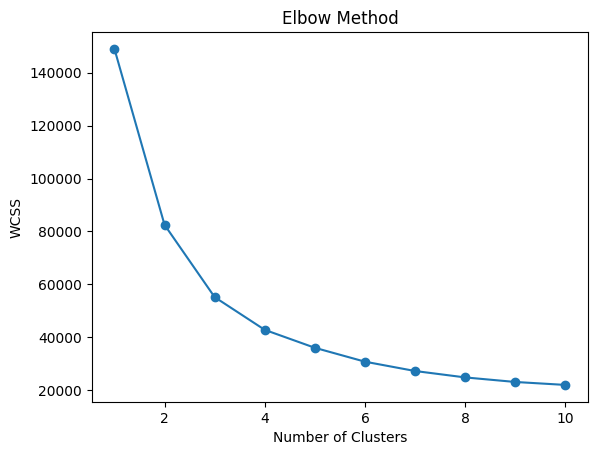

In [29]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [30]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [31]:
segment_profile = rfm.groupby('Cluster').mean()
segment_profile

,Recency,Frequency,Monetary
Cluster,,,
0,196.303943,3.420781,8540.961840
1,138.535687,8.536975,24754.201881
2,721.101699,2.924314,7797.505752
3,180.827512,5.803633,15927.435694


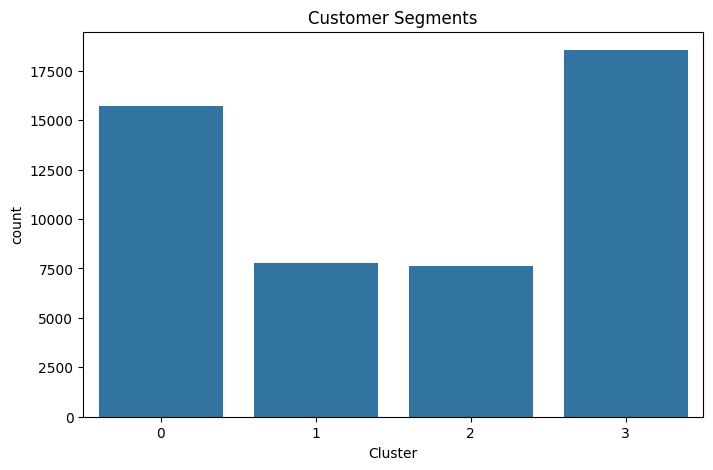

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=rfm)
plt.title('Customer Segments')
plt.show()

In [33]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue
best_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
best_products.head(10)

Product Category
Clothing       188688
Home           188077
Electronics    187861
Books          186608
Name: Quantity, dtype: int64

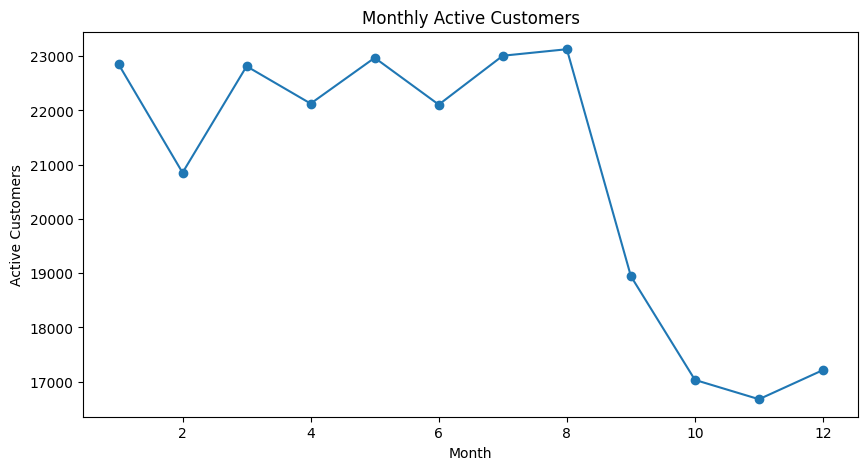

In [34]:
active_customers = df.groupby('Month')['Purchase Date'].nunique()
plt.figure(figsize=(10,5))
active_customers.plot(marker='o')
plt.title('Monthly Active Customers')
plt.xlabel('Month')
plt.ylabel('Active Customers')
plt.show()

In [35]:
rfm['Churn_Risk'] = np.where(rfm['Recency'] > 90, 1, 0)

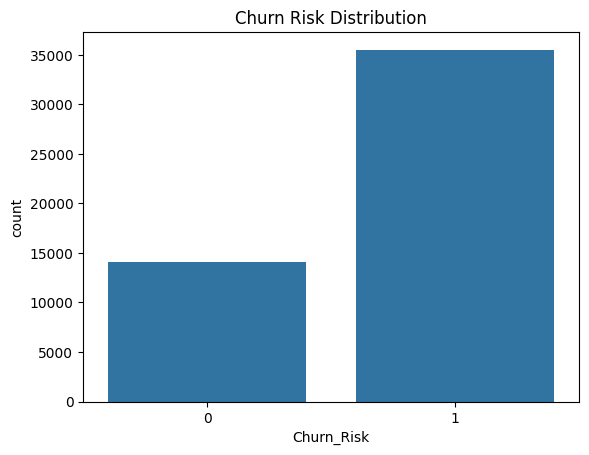

In [36]:
sns.countplot(x='Churn_Risk', data=rfm)
plt.title('Churn Risk Distribution')
plt.show()

In [37]:
rfm.to_csv('customer_segments.csv')

Three Actionable Insights
1. Large Contribution by High-Value Customers
-> A small percentage of clients contributes significantly to overall sales. These clients spend more frequently and on higher value products than average, and thus become very important for business success.
2.High Performance by Some Products and Poor Performance by Others
->It was found that certain products generate most of the sales and profits, while other products have less demand and are not very profitable. This creates an opportunity for targeted promotions.
3. Seasonality in Customer Purchases
-> Sales vary throughout the year, with some periods being more active and contributing to overall annual sales volume.

Five Recommendations
1. Introduce a Loyalty Program
Reward repeat customers using points, discounts, or cashback offers to improve retention.
2. Launch Personalized Marketing Campaigns
Use customer purchase history to send personalized recommendations and targeted promotions.
3. Re-engage Inactive Customers
Offer discounts and reminder campaigns to customers with high recency scores.
4. Focus on High-Performing Products
Increase promotions and inventory planning for products with consistently high sales.
5. Improve Customer Retention Strategies
Provide subscription benefits, referral programs, and customer support improvements to strengthen engagement.